In [1]:
%matplotlib inline
import lightkurve as lk
import matplotlib.pyplot as plt

In [17]:
import pandas as pd
import numpy as np
from astropy.timeseries import LombScargle
import astropy.units as u


In [ ]:
#search_result = lk.search_lightcurve('KI
search_result = lk.search_lightcurve('Kepler-10', author='Kepler')
search_result 
#C 3733346', author='Kepler')


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 01,2009,Kepler,1800,kplr010141900,0.0
1,Kepler Quarter 02,2009,Kepler,1800,kplr010141900,0.0
2,Kepler Quarter 03,2009,Kepler,1800,kplr010141900,0.0
3,Kepler Quarter 04,2010,Kepler,1800,kplr010141900,0.0
4,Kepler Quarter 05,2010,Kepler,1800,kplr010141900,0.0
5,Kepler Quarter 06,2010,Kepler,1800,kplr010141900,0.0
6,Kepler Quarter 07,2010,Kepler,1800,kplr010141900,0.0
7,Kepler Quarter 10,2011,Kepler,1800,kplr010141900,0.0
8,Kepler Quarter 09,2011,Kepler,1800,kplr010141900,0.0


In [4]:
lc = search_result.download()
lc

c:\Users\avery\OneDrive\Documents\GitHub\Astro502\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 17 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
131.51210258176434,7.9038833e+03,5.3517709e+00,0,1.108762e-03,599.93823,22.28257,1105,5.5589663e+03,3.7471619e+00,5.0756207e+02,4.1984275e-01,7.9038833e+03,5.3517709e+00,0,———,———,———,———,599.93823,1.0250738e-03,22.28257,9.8696072e-04,-7.1622333e-03,-1.1480066e-02
131.53253703520022,7.8861797e+03,5.3489013e+00,0,1.109515e-03,599.94313,22.28479,1106,5.5462529e+03,3.7460797e+00,4.8790936e+02,4.2016953e-01,7.8861797e+03,5.3489013e+00,0,———,———,———,———,599.94313,1.0301046e-03,22.28479,9.9066843e-04,-7.1246782e-03,-1.1585308e-02
131.5529713885262,7.8754302e+03,5.3447661e+00,10000000000000,1.110269e-03,599.94009,22.28302,1107,5.5397451e+03,3.7455609e+00,4.8308670e+02,4.1986713e-01,7.8754302e+03,5.3447661e+00,10000000000000,———,———,———,———,599.94009,1.0314080e-03,22.28302,9.9278009e-04,-7.2749164e-03,-1.1614930e-02
131.57340564184415,7.8914312e+03,5.3518286e+00,0,1.111022e-03,599.94289,22.28295,1108,5.5510879e+03,3.7463002e+00,4.8540427e+02,4.1978970e-01,7.8914312e+03,5.3518286e+00,0,———,———,———,———,599.94289,1.0305365e-03,22.28295,9.9115621e-04,-7.2589987e-03,-1.1646312e-02
131.59383999517013,7.8937485e+03,5.3524604e+00,0,1.111775e-03,599.94233,22.28406,1109,5.5508413e+03,3.7460477e+00,4.7674832e+02,4.1894391e-01,7.8937485e+03,5.3524604e+00,0,———,———,———,———,599.94233,1.0297651e-03,22.28406,9.9052233e-04,-7.2752149e-03,-1.1217996e-02
131.61427444838046,7.8900342e+03,5.3525090e+00,0,1.112528e-03,599.94107,22.28514,1110,5.5495938e+03,3.7462792e+00,4.7347739e+02,4.2009026e-01,7.8900342e+03,5.3525090e+00,0,———,———,———,———,599.94107,1.0297131e-03,22.28514,9.9067145e-04,-7.1847700e-03,-1.1236959e-02
131.63470870158926,7.8891187e+03,5.3531971e+00,0,1.113282e-03,599.94241,22.28640,1111,5.5485698e+03,3.7460883e+00,4.7222131e+02,4.2015815e-01,7.8891187e+03,5.3531971e+00,0,———,———,———,———,599.94241,1.0293552e-03,22.28640,9.8990917e-04,-7.1167052e-03,-1.1122936e-02
131.65514305479155,7.8902651e+03,5.3502679e+00,0,1.114035e-03,599.94421,22.28784,1112,5.5495039e+03,3.7461512e+00,5.0097574e+02,4.2045763e-01,7.8902651e+03,5.3502679e+00,0,———,———,———,———,599.94421,1.0271642e-03,22.28784,9.8737539e-04,-7.0360736e-03,-1.1076232e-02


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

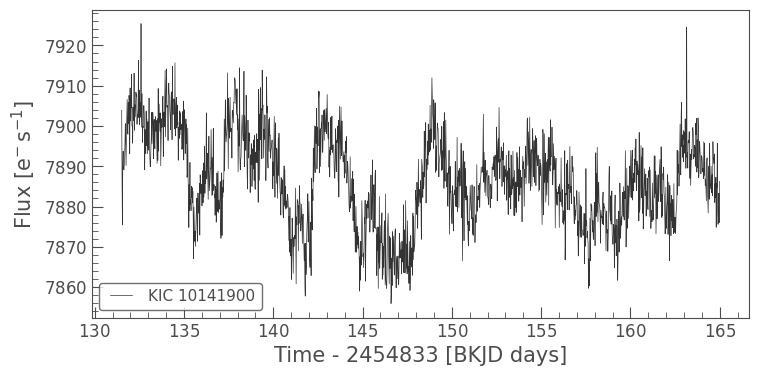

In [5]:
lc.plot()
#plt.savefig('C:/Users/smithlt/Documents/ASTR502/test_light_curve.png') 

In [6]:
lc_collection = search_result[:5].download_all()
lc_collection

LightCurveCollection of 5 objects:
    0: <KeplerLightCurve LABEL="KIC 10141900" QUARTER=1 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    1: <KeplerLightCurve LABEL="KIC 10141900" QUARTER=2 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    2: <KeplerLightCurve LABEL="KIC 10141900" QUARTER=3 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    3: <KeplerLightCurve LABEL="KIC 10141900" QUARTER=4 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    4: <KeplerLightCurve LABEL="KIC 10141900" QUARTER=5 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

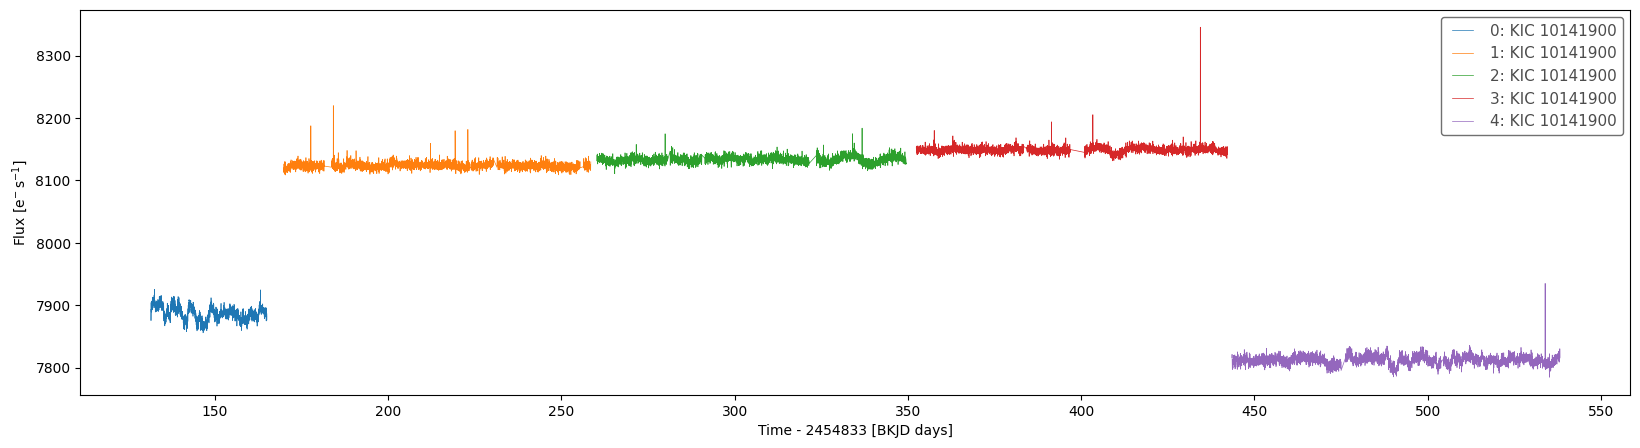

In [8]:
fig, ax = plt.subplots(figsize=(20,5))
lc_collection.plot(ax=ax)
#plt.savefig('C:/Users/smithlt/Documents/ASTR502/test_light_curve_collection.png')

In [9]:
print(lc.time)

print(lc.flux)

[131.51210258 131.53253704 131.55297139 ... 164.9425855  164.96301958
 164.98345376]
[7903.8833 7886.1797 7875.43   ... 7883.2954 7875.9746 7886.234 ] electron / s


In [12]:
#initial Lomb-Scargle attempt, returns NaN values for the power
time = lc['time'].value
flux = lc['flux'].value

print(time)
print(flux)

frequency, power = LombScargle(time, flux).autopower(minimum_frequency=1/20, maximum_frequency=10)

print(frequency)
print(power)

[131.51210258 131.53253704 131.55297139 ... 164.9425855  164.96301958
 164.98345376]
[7903.8833 7886.1797 7875.43   ... 7883.2954 7875.9746 7886.234 ]
[0.05       0.05597526 0.06195052 ... 9.9868561  9.99283135 9.99880661]
[nan nan nan ... nan nan nan]


In [ ]:
# convert to plain numpy arrays (strip astropy Quantity units if present)
time = lc.time.value if hasattr(lc.time, "value") else np.asarray(lc.time)
flux = lc.flux.value if hasattr(lc.flux, "value") else np.asarray(lc.flux)

# remove NaNs / infinities
mask = np.isfinite(time) & np.isfinite(flux)
time = time[mask]
flux = flux[mask]

frequency, power = LombScargle(time, flux).autopower(minimum_frequency=1/20, maximum_frequency=10)

print(frequency)
print(power)

[0.05       0.05597526 0.06195052 ... 9.9868561  9.99283135 9.99880661]
[0.07753532 0.10010745 0.11393809 ... 0.00057113 0.0007508  0.00085347]


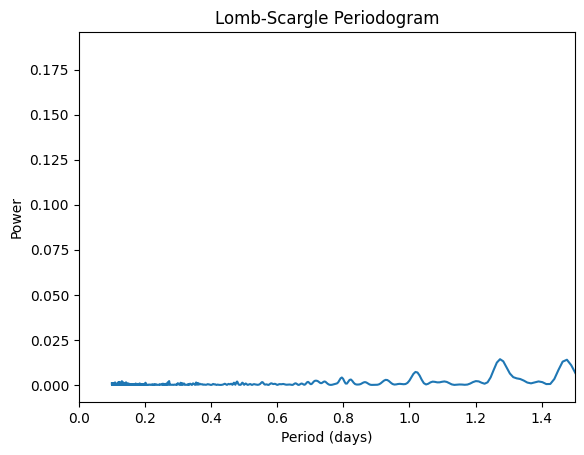

In [15]:
#fig, ax = plt.subplots()
plt.plot(1/frequency, power)
plt.xlabel('Period (days)')
plt.ylabel('Power')
plt.title('Lomb-Scargle Periodogram')
plt.xlim(0, 1.5) #changed the bounds to more accurately determine the period
#plt.savefig('C:/Users/smithlt/Documents/ASTR502/test_lomb_scargle_periodogram.png')
plt.show()

In [16]:
#identifying the period that corresponds to the highest peak in the Lomb-Scargle periodogram
peak_frequency = frequency[np.argmax(power)]
peak_power = 1 / peak_frequency

print(f"Identified period: {peak_power} days")

Identified period: 5.3352977974328 days


In [45]:
#load the full mega target list
#had to move this to a separate directory because there were issues accessing the file from github
targets = pd.read_csv("C:\\Users\\smithlt\\Documents\\ASTR502\\ASTR502_Mega_Target_List.csv")

print(f"Loaded {len(targets)} total targets from CSV")
print(f"Columns available: {list(targets.columns)}")

# Check what mission sources we have
if 'mission_source' in targets.columns:
    print(f"\nMission sources in dataset:")
    print(targets['mission_source'].value_counts())
    
    # Filter for only Kepler targets
    kepler_targets = targets[targets['mission_source'] == 'Kepler'].copy()
    print(f"\nFound {len(kepler_targets)} Kepler targets!")
    
    if len(kepler_targets) > 0:
        print("\nFirst 5 Kepler targets:")
        for i, row in kepler_targets.head().iterrows():
            print(f"  {row['pl_name']}: {row['tic_id']}")
    else:
        print("No Kepler targets found in the dataset.")
        print("Let's check for targets that might have Kepler data...")
        
        # Look for targets that might have sy_kepmag (Kepler magnitude)
        if 'sy_kepmag' in targets.columns:
            kepler_mag_targets = targets[pd.notna(targets['sy_kepmag'])].copy()
            print(f"Found {len(kepler_mag_targets)} targets with Kepler magnitudes")
            if len(kepler_mag_targets) > 0:
                print("First 5 targets with Kepler magnitudes:")
                for i, row in kepler_mag_targets.head().iterrows():
                    print(f"  {row['pl_name']}: {row['tic_id']}, Kepler mag: {row['sy_kepmag']}")
                kepler_targets = kepler_mag_targets
else:
    print("No 'mission_source' column found. Let's look for other Kepler indicators...")
    
    # Look for targets that might have sy_kepmag
    if 'sy_kepmag' in targets.columns:
        kepler_targets = targets[pd.notna(targets['sy_kepmag'])].copy()
        print(f"Found {len(kepler_targets)} targets with Kepler magnitudes")
    else:
        print("No clear Kepler indicators found in the dataset.")
        kepler_targets = pd.DataFrame()

print(f"\nFinal Kepler target count: {len(kepler_targets)}")

# Test a few Kepler targets quickly to see what works
if len(kepler_targets) > 0:
    print("\nTesting search methods on first 3 Kepler targets...")
    test_sample = kepler_targets.head(5)
    
    working_kepler_targets = []
    
    for i, row in test_sample.iterrows():
        target_name = row['pl_name']
        tic_id = row['tic_id']
        
        print(f"\nTesting {target_name} ({tic_id}):")
        
        # Try different search strategies
        search_strategies = [
            f"{tic_id}",
            f"{tic_id}",
            target_name.split()[0] if len(target_name.split()) > 1 else target_name
        ]
        
        found_data = False
        for search_term in search_strategies:
            try:
                kepler_result = lk.search_lightcurve(search_term, author='Kepler')

                if len(kepler_result) > 0:
                    print(f"  ✓ '{search_term}': {len(kepler_result)} Kepler results")
                    working_kepler_targets.append({
                        'target_name': target_name,
                        'tic_id': tic_id,
                        'search_term': search_term,
                        'kepler_results': len(kepler_result),
                    })
                    found_data = True
                    break
                else:
                    print(f"  ✗ '{search_term}': No results")
            except Exception as e:
                print(f"  ✗ '{search_term}': Error - {e}")
        
        if not found_data:
            print(f"No data found for {target_name}")
    
    print(f"\n✓ Found {len(working_kepler_targets)} Kepler targets with available data")
    
    if working_kepler_targets:
        # DataFrame for processing
        kepler_star_df = pd.DataFrame(working_kepler_targets)
        print("\nReady to process these Kepler targets:")
        for i, row in kepler_star_df.iterrows():
            print(f"  {row['target_name']}: {row['search_term']} ({row['kepler_results']} Kepler)")
    else:
        print("No working Kepler targets found in the test sample")
else:
    print("No Kepler targets to test")

Loaded 4516 total targets from CSV
Columns available: ['pl_name', 'hostname', 'gaia_dr3_id', 'gaia_dr2_id', 'tic_id', 'hd_name', 'ra', 'dec', 'sy_vmag', 'sy_jmag', 'sy_kmag', 'sy_tmag', 'sy_kepmag', 'sy_gaiamag', 'st_teff', 'st_logg', 'st_met', 'st_mass', 'st_rad', 'st_spectype', 'st_lum', 'st_age', 'st_ageerr1', 'st_ageerr2', 'st_rotp', 'pl_orbper', 'pl_rade', 'pl_trandur', 'disc_facility', 'disc_year', 'mission_source']

Mission sources in dataset:
mission_source
Kepler    2762
TESS       717
K2         548
WASP       168
HAT        139
Other      105
CoRoT       34
NGTS        22
KELT        21
Name: count, dtype: int64

Found 2762 Kepler targets!

First 5 Kepler targets:
  Kepler-1629 b: TIC 351766445
  Kepler-1445 b: TIC 351766604
  Kepler-1286 b: TIC 351766517
  Kepler-1835 b: TIC 351799800
  Kepler-1341 b: TIC 123126460

Final Kepler target count: 2762

Testing search methods on first 3 Kepler targets...

Testing Kepler-1629 b (TIC 351766445):
  ✓ 'TIC 351766445': 18 Kepler resu

Processing 5 Kepler targets with available data...

Processing target 1/5: Kepler-1629 b
TIC ID: TIC 351766445, Search term: TIC 351766445
Found 18 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 120.5 - 130.2 days
  Data points: 473
  Clean data points: 469
  ✓ Period analysis complete:
    Peak period: 6.3801 days
    Peak power: 0.7350


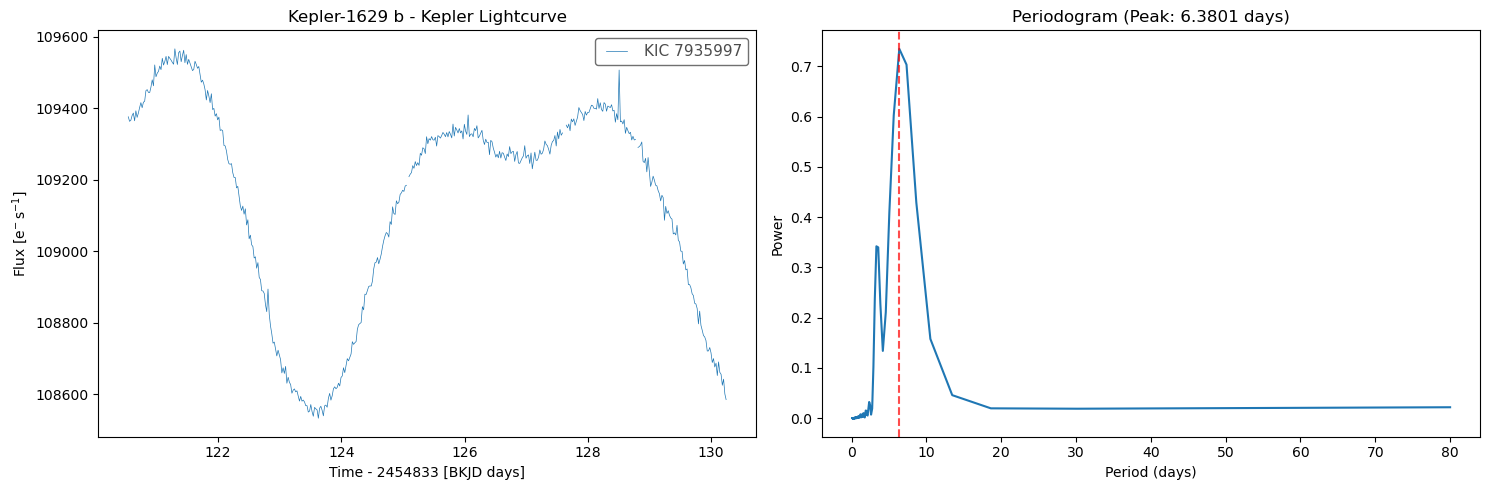


Processing target 2/5: Kepler-1445 b
TIC ID: TIC 351766604, Search term: TIC 351766604
Found 18 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 120.5 - 130.2 days
  Data points: 473
  Clean data points: 469
  ✓ Period analysis complete:
    Peak period: 10.5351 days
    Peak power: 0.1896


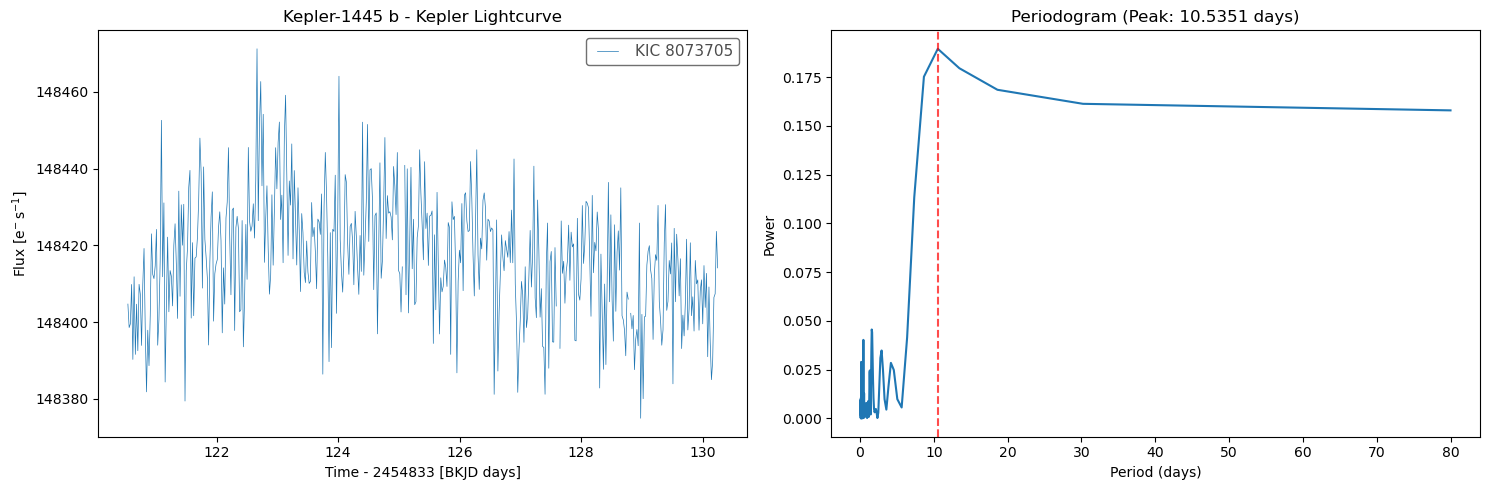


Processing target 3/5: Kepler-1286 b
TIC ID: TIC 351766517, Search term: TIC 351766517
Found 9 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 131.5 - 165.0 days
  Data points: 1626
  Clean data points: 1624
  ✓ Period analysis complete:
    Peak period: 20.6817 days
    Peak power: 0.0853


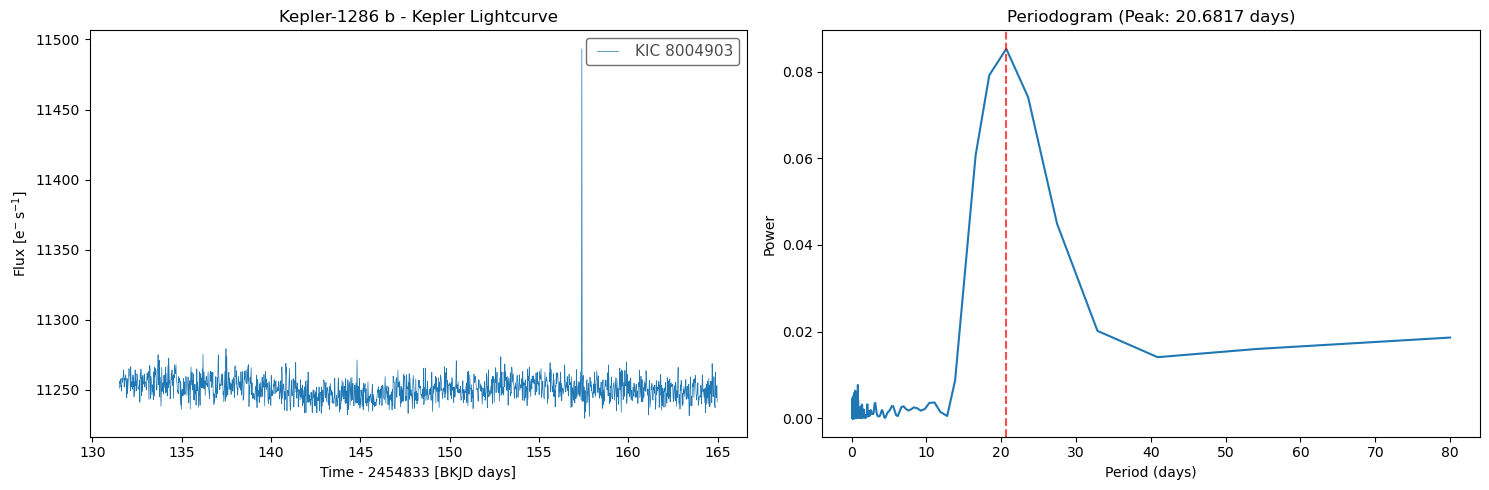


Processing target 4/5: Kepler-1835 b
TIC ID: TIC 351799800, Search term: TIC 351799800
Found 9 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 131.5 - 165.0 days
  Data points: 1626
  Clean data points: 1624
  ✓ Period analysis complete:
    Peak period: 80.0000 days
    Peak power: 0.0836


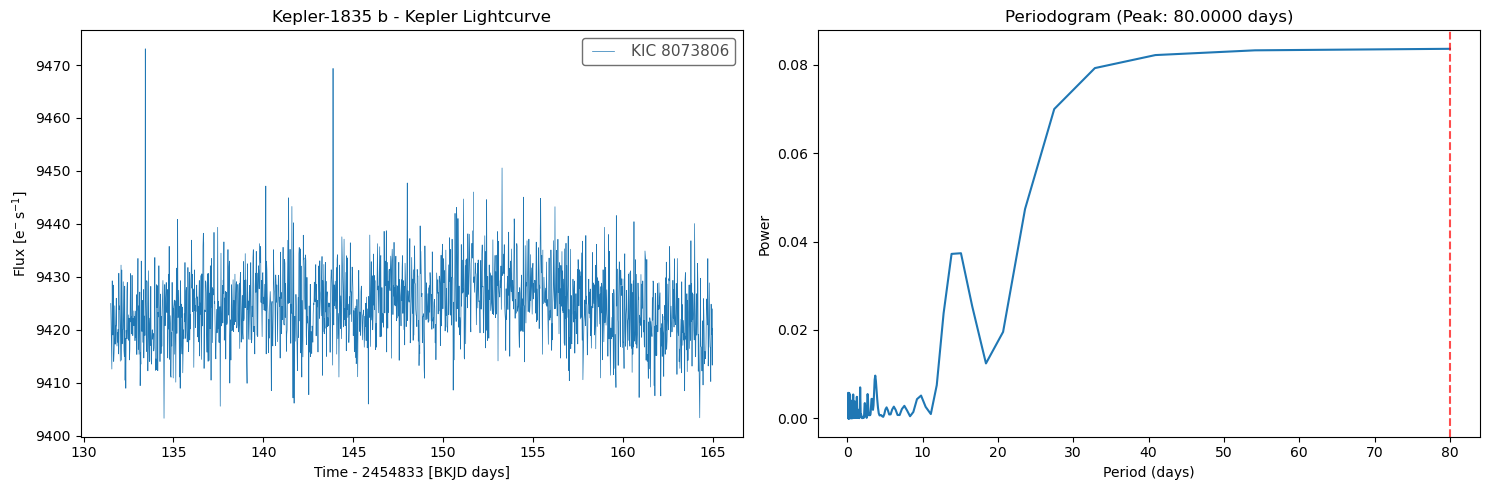


Processing target 5/5: Kepler-1341 b
TIC ID: TIC 123126460, Search term: TIC 123126460
Found 17 quarters of Kepler data
✓ Successfully downloaded Kepler lightcurve
  Time span: 131.5 - 165.0 days
  Data points: 1626
  Clean data points: 1624
  ✓ Period analysis complete:
    Peak period: 23.5980 days
    Peak power: 0.8405


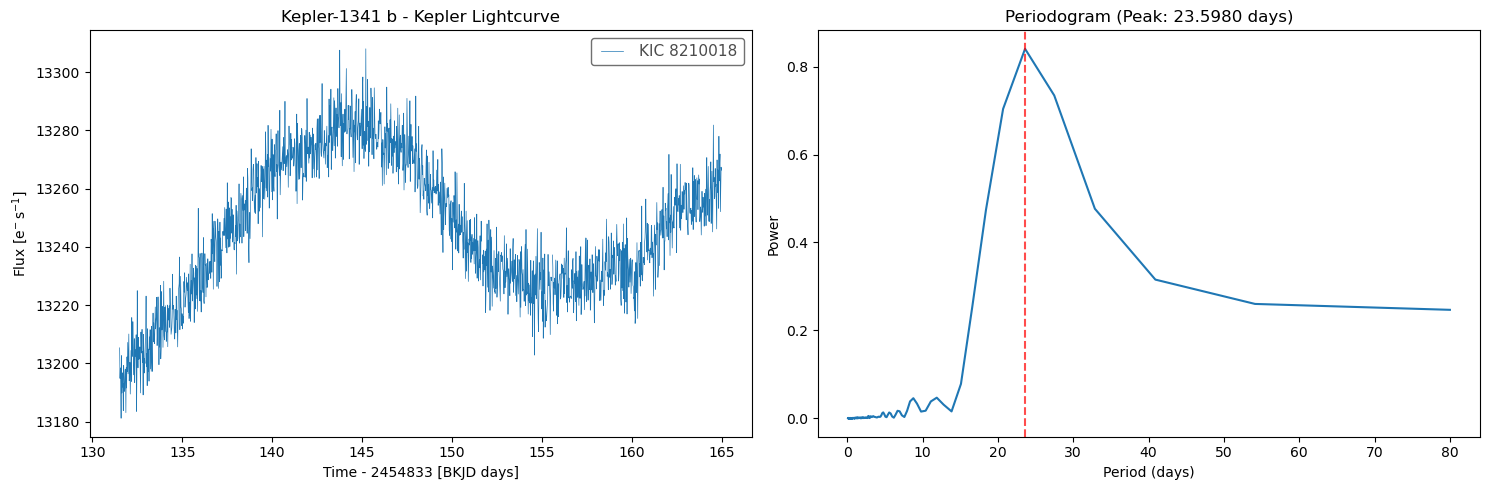


FINAL SUMMARY
Kepler targets processed: 5
Successful analyses: 5

Successful targets:
  Kepler-1629 b: 6.3801 days (Kepler)
  Kepler-1445 b: 10.5351 days (Kepler)
  Kepler-1286 b: 20.6817 days (Kepler)
  Kepler-1835 b: 80.0000 days (Kepler)
  Kepler-1341 b: 23.5980 days (Kepler)

Period statistics:
  Average: 28.2390 days
  Range: 6.3801 - 80.0000 days
  Median: 20.6817 days


In [46]:
if 'kepler_star_df' in locals() and len(kepler_star_df) > 0:
    print(f"Processing {len(kepler_star_df)} Kepler targets with available data...")

    best_periods = []
    successful_analyses = 0
    target_results = []

    for i, row in kepler_star_df.iterrows():
        target_name = row['target_name'] 
        search_term = row['search_term']
        tic_id = row['tic_id']
        
        print(f"\n{'='*50}")
        print(f"Processing target {i+1}/{len(kepler_star_df)}: {target_name}")
        print(f"TIC ID: {tic_id}, Search term: {search_term}")
        
        try:
            # Search for Kepler 
            kepler_search = lk.search_lightcurve(search_term, author='Kepler')
            
            # Process Kepler data first if available
            if len(kepler_search) > 0:
                print(f"Found {len(kepler_search)} quarters of Kepler data")
                
                # Download first quarter only to keep it fast
                lc = kepler_search[0].download()
                
                if lc is not None:
                    mission_name = 'Kepler'
                    print(f"✓ Successfully downloaded Kepler lightcurve")
                    print(f"  Time span: {lc.time.min().value:.1f} - {lc.time.max().value:.1f} days")
                    print(f"  Data points: {len(lc.time)}")
                    
                    # process the lightcurve
                    time = lc.time.value if hasattr(lc.time, "value") else np.asarray(lc.time)
                    flux = lc.flux.value if hasattr(lc.flux, "value") else np.asarray(lc.flux)

                    # remove NaNs / infinities
                    mask = np.isfinite(time) & np.isfinite(flux)
                    clean_time = time[mask]
                    clean_flux = flux[mask]

                    
                    if len(clean_time) > 100:  #get enough points for analysis
                        print(f"  Clean data points: {len(clean_time)}")
                        
                        # Lomb-Scargle analysis
                        freq, power = LombScargle(clean_time, clean_flux).autopower(
                            minimum_frequency=1/80, maximum_frequency=10
                        )
                        
                        #find peak
                        peak_freq = freq[np.argmax(power)]
                        peak_period = 1/peak_freq
                        peak_power = np.max(power)
                        
                        print(f"  ✓ Period analysis complete:")
                        print(f"    Peak period: {peak_period:.4f} days")
                        print(f"    Peak power: {peak_power:.4f}")
                        
                        #store results
                        target_results.append({
                            'target_name': target_name,
                            'tic_id': tic_id,
                            'mission': mission_name,
                            'period': peak_period,
                            'power': peak_power,
                            'data_points': len(clean_time)
                        })
                        
                        best_periods.append(peak_period)
                        successful_analyses += 1
                    
                        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
                        
                        #lightcurve plot
                        lc.plot(ax=ax1)
                        ax1.set_title(f'{target_name} - Kepler Lightcurve')
                        
                        # Periodogram
                        ax2.plot(1/freq, power)
                        ax2.set_xlabel('Period (days)')
                        ax2.set_ylabel('Power')
                        ax2.set_title(f'Periodogram (Peak: {peak_period:.4f} days)')
                        ax2.axvline(peak_period, color='red', linestyle='--', alpha=0.7)
                        
                        plt.tight_layout()
                        plt.show()
                        
                    else:
                        print(f"Not enough clean data points ({len(clean_time)})")
                else:
                    print(f"Failed to download Kepler data")
                    
        except Exception as e:
            print(f"Error processing {target_name}: {e}")
            continue

    #final summary
    print(f"\n{'='*50}")
    print(f"FINAL SUMMARY")
    print(f"{'='*50}")
    print(f"Kepler targets processed: {len(kepler_star_df)}")
    print(f"Successful analyses: {successful_analyses}")
    
    if target_results:
        results_df = pd.DataFrame(target_results)
        print(f"\nSuccessful targets:")
        for i, row in results_df.iterrows():
            print(f"  {row['target_name']}: {row['period']:.4f} days ({row['mission']})")
        
        if len(best_periods) > 1:
            print(f"\nPeriod statistics:")
            print(f"  Average: {np.mean(best_periods):.4f} days")
            print(f"  Range: {np.min(best_periods):.4f} - {np.max(best_periods):.4f} days")
            print(f"  Median: {np.median(best_periods):.4f} days")
    else:
        print("No successful analyses completed")
        
else:
    print("No Kepler targets available. Please run the previous cell first to identify Kepler targets.")